<a href="https://colab.research.google.com/github/DiegoLopezAroca/Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry/blob/main/Advanced_ML_D2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Advanced ML - D2.2: Final submission**
In this final submission of, we will apply all the forecasting material seen in class to the dataset covered in the previous delivery. We will go over each section required, providing code and the corresponding explaination at each time.

This delivery, plus all the previous work carried with the selected dataset will be available in the following GitHub repository link. [``Github repository``](https://github.com/DiegoLopezAroca/Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry).

## **Steel Industry Energy Consumption**
Sourced and available from the well known *UCI Machine Learning Repository*, the selected dataset collects the energy consumption data over time from a company in charge of manufacturing different steel pieces such as coils, steel and iron plates.

<img src="https://imgs.search.brave.com/ESvN_gCRRKdWbUcO7p8AkLrhO1BaXxMl-yZXC8V-Plg/rs:fit:500:0:1:0/g:ce/aHR0cHM6Ly9zdGF0/aWMudmVjdGVlenku/Y29tL3N5c3RlbS9y/ZXNvdXJjZXMvdGh1/bWJuYWlscy8wNjYv/MzY5LzQxOS9zbWFs/bC9pbmR1c3RyaWFs/LW1ldGFsLXdpcmUt/Y29pbHMtY29pbHMt/b2YtbWV0YWwtd2ly/ZS1hcmUtc3RhY2tl/ZC1vbi1hLWxvYWRp/bmctZG9jay1pbi1h/LWxhcmdlLWluZHVz/dHJpYWwtZmFjaWxp/dHktZHVyaW5nLWRh/eWxpZ2h0LWhvdXJz/LXBob3RvLmpwZw" width="250">

<img src="https://imgs.search.brave.com/PZ3OMLbjSqIO4KVhCtt7duTpXzryO8z7jjU3yPuUIuI/rs:fit:500:0:1:0/g:ce/aHR0cHM6Ly9zdGF0/aWMudmVjdGVlenku/Y29tL3N5c3RlbS9y/ZXNvdXJjZXMvdGh1/bWJuYWlscy8wNzEv/NDYzLzI4NC9zbWFs/bC9zdGFjay1vZi1z/dGVlbC1wbGF0ZXMt/aW5kdXN0cmlhbC1t/ZXRhbC1zaGVldHMt/bWV0YWwtY29uc3Ry/dWN0aW9uLW1hdGVy/aWFscy1jbG9zZS11/cC1waG90by5qcGc" width="250">

We won't cover the dataset analysis as that work was already tackled in the previous submission.


# Dataset loading & Dependencies

In [12]:
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf


In [4]:
auth.authenticate_user()
google_auth = GoogleAuth()
google_auth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(google_auth)
file_id = '1FLKVRjZcWCm3zBcNElhfEZm3KAzRW3PQ'
file = drive.CreateFile({'id':file_id})
file.GetContentFile('steel_industry_energy_dataset.csv')

df = pd.read_csv('steel_industry_energy_dataset.csv')
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


As in the previous submission, we will cast the required variables to work with datetime feature types.

In [5]:
df["date"] = pd.to_datetime(df["date"], format="%d/%m/%Y %H:%M")

# Time Series Analysis
Even if we already covered part of this analysis in the previous work, we will still include it for a more compact study on the forecasting properties of the dataset. Furthermore, we would like to clear some of the previous analysis which may have been a little confusing.

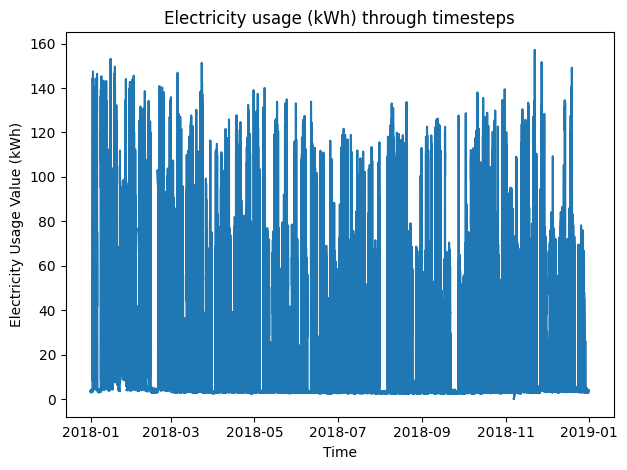

In [8]:
def visualize_time_series(dataframe):
    fig, ax = plt.subplots()
    ax.plot(dataframe["date"], dataframe["Usage_kWh"])
    ax.set_xlabel('Time') # Is just the sequential order
    ax.set_ylabel('Electricity Usage Value (kWh)')
    plt.title("Electricity usage (kWh) through timesteps")
    plt.tight_layout()

visualize_time_series(df)

In [10]:
ADF_result = adfuller(df['Usage_kWh']) # Apply to the time series column
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]:.4f}')

ADF Statistic: -24.281836827446373
p-value: 0.0000


As the p-value is less than 0.05 we can reject the null hypothesis and confirm that the time series is stationary (constant mean and variance). But as we looked more into it we saw that the lag in autocorrelation was decaying suprisingly slow. This suggests that there could be a random walk not being detected because the way in which the plant is shutted down every day is biasing the test. **ZUZENDU BEHARRA ARITZEK ESANDAKOA**

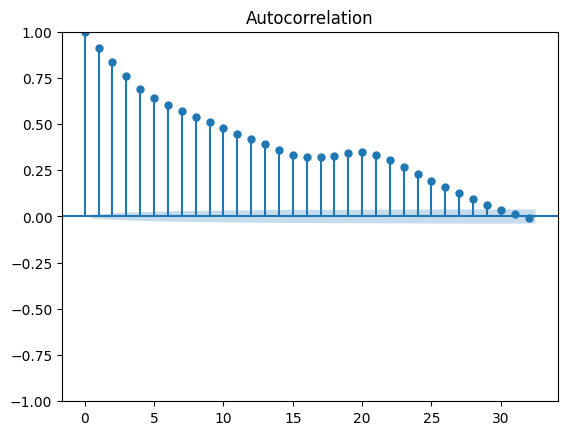

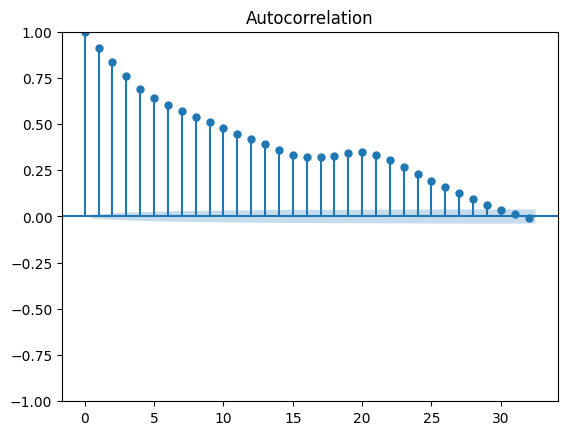

In [11]:
plot_acf(df['Usage_kWh'], lags=32)

Its curious to see that the lag is so big. This has lead us to think that maybe the adf test was being affected by the fact that each day the production plant is completely shut down. To prove that, we can analyze the partial autocorrelation. While the standard ACF showed a slow decay, which can mean that the data is not stationary, the PACF shows the direct relationship between a timestamp and its previous lags, removing the influence of intermediate steps.

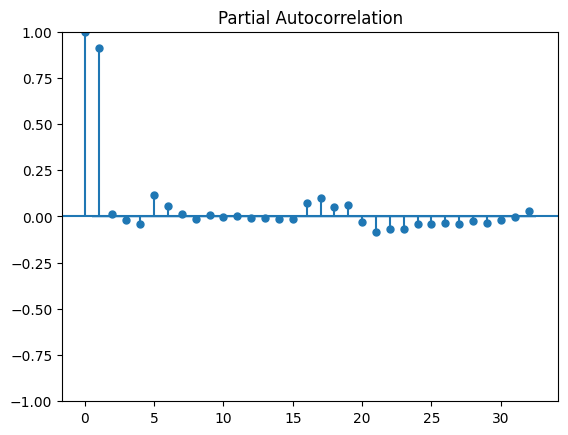

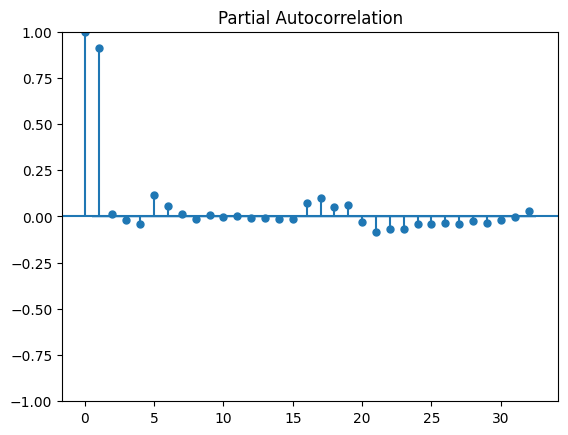

In [13]:
plot_pacf(df['Usage_kWh'], lags=32)

The fact that the PACF falls suddenly after the first lag confirms that the series is dominated by short-term, a characteristic of a Random Walk that is being reseted to zero every day by the plant's operational schedule.

## Dataset Splitting
As mentioned in the previous delivery, our goal is to predict the future 24h electric consumption based on the 15 minutes intervals, recorded during the day for one complete year. The rationale behind this decision is that a 24 hour horizon permits the factory/plant to adjust their production times based on the cost of energy and ensure that the renewable energy supply is enough.

In order to perform the train/test dataset splitting, we must ensure we take the test set as 15 minute intervals of the last 24 hour recordings of our dataset. The number of points or instances that will go directly to the test set can be calculated like: **24 (hours) * 60 (minutes/hour) / 15 (minutes per interval) = 96**. Then, 96 instances will go to the test set, while all the rest will go to the training set.

In [22]:
test_size = int(24 * 60 / 15)
print(f"Number of test instances: {test_size}")

train_size = len(df) - test_size
print(f"Number of train instances: {train_size}")

# Dataset splitting method we have seen in class
train = df.iloc[:train_size]
test = df.iloc[train_size:] # Start test set from the end of the train set

print(f"Total data points: {len(df)}")
print(f"\nTrain data start: {train['date'].min()} / end: {train['date'].max()}")
print(f"Test data start: {test['date'].min()} / end: {test['date'].max()}")

Number of test instances: 96
Number of train instances: 34944
Total data points: 35040

Train data start: 2018-01-01 00:00:00 / end: 2018-12-30 23:45:00
Test data start: 2018-12-31 00:00:00 / end: 2018-12-31 23:45:00


Once splitted the dataset into the desired format, let's visualize it once again but differencing the train and test sets.

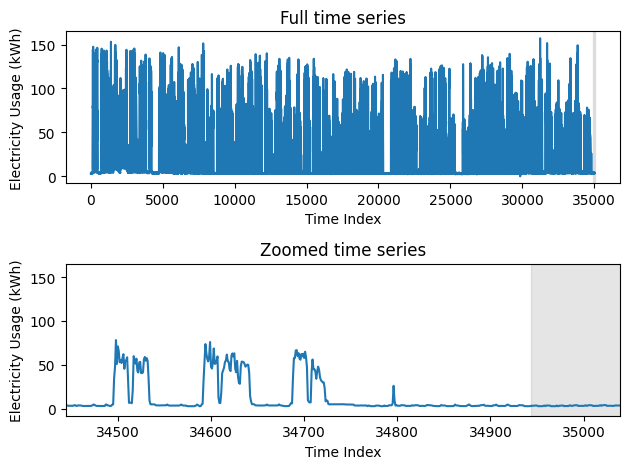

In [48]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=False)

ax1.plot(df.index, df["Usage_kWh"])
ax1.set_xlabel("Time Index")
ax1.set_ylabel('Electricity Usage (kWh)')
ax1.set_title('Full time series')
ax1.axvspan(train_size, len(df), color='#808080', alpha=0.2)

ax2.plot(df.index, df["Usage_kWh"])
ax2.set_xlabel("Time Index")
ax2.set_ylabel('Electricity Usage (kWh)')
ax2.set_title('Zoomed time series')
ax2.axvspan(train_size, len(df), color='#808080', alpha=0.2)

# This will ensure the second plot is a zoomed version of the first
zoom_start_index = train_size - 500
if zoom_start_index < 0: #
    zoom_start_index = 0
ax2.set_xlim(zoom_start_index, len(df) - 1)

plt.tight_layout()

As showed in the previous graphs the test set takes a tiny part of the whole time series, so we have plotted a second graph to see more in detail the portion the test set will have.

# ARMA
Results obtained using this modeling procedure. If it is not possible to apply it,
justify why.

# SARIMA (General modeling procedure)


*   Results obtained using this modeling procedure. Test at least two different
combinations of p (order of autoregression) and q (order of moving average).
*   If seasonality is present, consider employing a naïve approach to manage this
characteristic using ARIMA.



# AutoArima or SARIMAX (if we have exogenous variables)


*   Results obtained using this modeling procedure.
*   With and without seasonality.



# Transformer based architecture
 Use one transformers-based architecture for time series forecasting.

# Results discussion


*   Present the results obtained from your models, applying the same metric across all the models. Establish some baselines (last known value, mean, naïve seasonal…).
*   Use a table to compare all the results
*    Highlight any interesting findings observed during your analysis.





# Lessons learned


*   Identify key challenges you faced during the project and how you overcame them.
*   Share any insights gained from working with time series and from selecting specific parameters (window, horizon, range of values for q and p…).

